# LLM vs LLM

### 250 conversations/condition, 6 turns 

In [12]:
import json
import pandas as pd

scores_path = "/users/eleves-a/2023/allegra-maria-pia.boustany/llm-cross-eval/src/data/scores/output_scores_20260128_071446.jsonl"  

rows = []
with open(scores_path, "r") as f:
    for line in f:
        if line.strip():
            rows.append(json.loads(line))

df = pd.DataFrame(rows)

In [13]:
# nll per token
df["nll_per_token"] = -df["avg_logprob"]
df["nll_total"] = df["nll_per_token"] * df["n_tokens"]


In [14]:
# average by condition x n_turns_context
agg = (
    df.groupby(["condition", "n_turns_context"])["nll_per_token"]
      .mean()
      .reset_index()
      .sort_values("n_turns_context")
)
agg


,condition,n_turns_context,nll_per_token
0,hidden_persona,0,3.141895
6,no_persona,0,3.232534
1,hidden_persona,1,2.336663
7,no_persona,1,2.183894
2,hidden_persona,2,1.939495
8,no_persona,2,1.627071
3,hidden_persona,3,1.940031
9,no_persona,3,1.641357
4,hidden_persona,4,1.945695
10,no_persona,4,1.665925


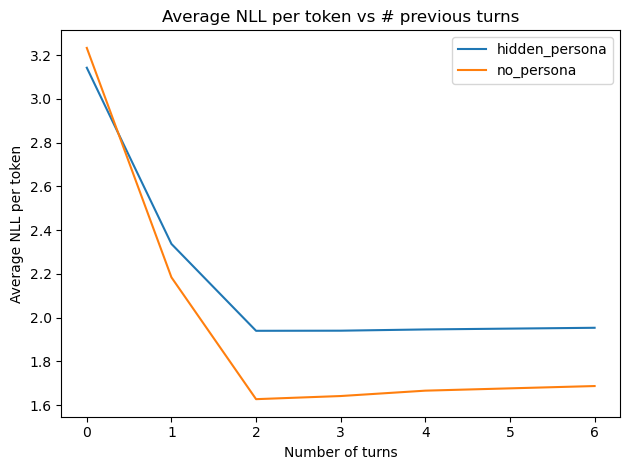

In [16]:
import matplotlib.pyplot as plt

plt.figure()
for cond, sub in agg.groupby("condition"):
    plt.plot(sub["n_turns_context"], sub["nll_per_token"], label=cond)

plt.title("Average NLL per token vs # previous turns")
plt.xlabel("Number of turns")
plt.ylabel("Average NLL per token")
plt.legend()
plt.tight_layout()
plt.show()


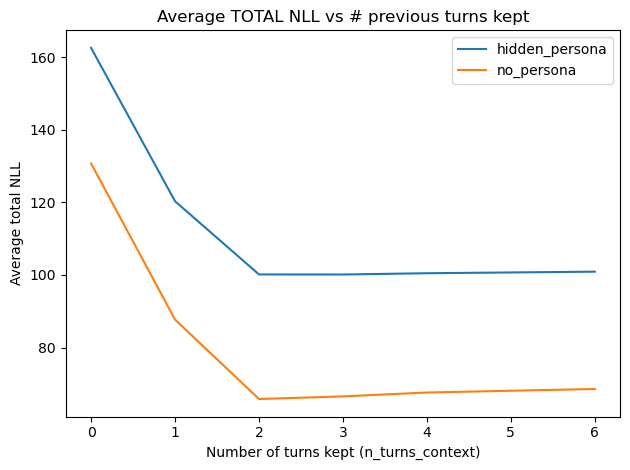

In [10]:
agg2 = (
    df.groupby(["condition", "n_turns_context"])["nll_total"]
      .mean()
      .reset_index()
      .sort_values("n_turns_context")
)

plt.figure()
for cond, sub in agg2.groupby("condition"):
    plt.plot(sub["n_turns_context"], sub["nll_total"], label=cond)

plt.title("Average TOTAL NLL vs # previous turns kept")
plt.xlabel("Number of turns kept (n_turns_context)")
plt.ylabel("Average total NLL")
plt.legend()
plt.tight_layout()
plt.show()


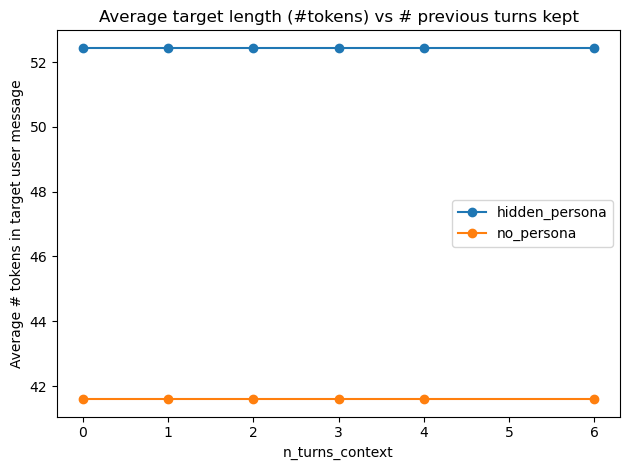

In [11]:
import matplotlib.pyplot as plt

tok_agg = (
    df.groupby(["condition", "n_turns_context"])["n_tokens"]
      .mean()
      .reset_index()
      .sort_values("n_turns_context")
)

plt.figure()
for cond, sub in tok_agg.groupby("condition"):
    plt.plot(sub["n_turns_context"], sub["n_tokens"], marker="o", label=cond)

plt.title("Average target length (#tokens) vs # previous turns kept")
plt.xlabel("n_turns_context")
plt.ylabel("Average # tokens in target user message")
plt.legend()
plt.tight_layout()
plt.show()
